# ARIA v2 Homework 4

This notebook upgrades the Week 3 river-distance workflow with terrain intelligence. The default target county is **花蓮縣**, but the workflow is now parameterized and is not limited to Hualien.

**Workflow summary**

1. Load the shelter, river, township, and DEM inputs from Google Drive.
2. Read `.env` settings, especially `TARGET_COUNTY`, and build the target county boundary plus buffer.
3. Rebuild the Week 3 river-distance analysis for the selected county.
4. Automatically clip the full Taiwan DEM to the selected county extent, then compute slope and terrain statistics.
5. Merge river risk and terrain risk into a final shelter risk table and export the required visuals.

To generate results for another county, you only need to change `TARGET_COUNTY` in `Colab Notebooks/.env` and rerun the notebook. When a full Taiwan DEM is provided, the code will automatically clip that DEM to the selected county before analysis.

The assignment-required visualization still includes a slope-vs-elevation scatter plot for the Top 10 high-risk shelters. Because dense counties such as New Taipei can cause labels to overlap badly in a static scatter figure, this notebook also exports a supplementary ranked chart for readability.

**Deliverables generated by this notebook**

- `terrain_risk_audit.json`
- `terrain_risk_map.png`
- `terrain_risk_top10_scatter.png`
- `terrain_risk_top10_ranked.png` (supplementary readability chart)

Each major step includes a Captain's Log note so the analysis is easy to follow during grading.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!apt-get update -qq
!apt-get install -y fonts-noto-cjk

%pip install -q geopandas rioxarray rasterstats python-dotenv matplotlib pyogrio rasterio shapely xarray


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 142 not upgraded.


font_path = /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc
font_name = Noto Sans CJK JP


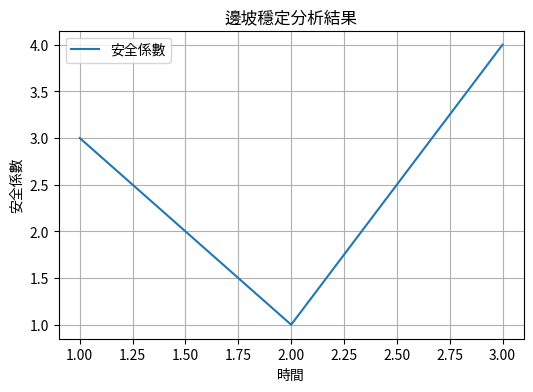

In [2]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 直接指定字型檔路徑
font_path_candidates = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSerifCJK-Regular.ttc",
    "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
]

font_path = None
for p in font_path_candidates:
    if os.path.exists(p):
        font_path = p
        break

print("font_path =", font_path)

# 把字型加入 matplotlib
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

print("font_name =", font_name)

# 全域設定
mpl.rcParams["font.family"] = font_name
mpl.rcParams["axes.unicode_minus"] = False

# 測試
plt.figure(figsize=(6,4))
plt.plot([1,2,3], [3,1,4], label="安全係數")
plt.title("邊坡穩定分析結果")
plt.xlabel("時間")
plt.ylabel("安全係數")
plt.legend(prop=font_prop)
plt.grid(True)
plt.show()


## Captain's Log 1

Lock the Colab paths first. The notebook lives in `Colab Notebooks`, and the raw inputs live in `Colab Notebooks/data`. This version can use either a county-specific DEM or a full Taiwan DEM, then clip it down to the target county before terrain analysis.


In [3]:
from pathlib import Path
import os
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import rioxarray
import xarray as xr
from dotenv import load_dotenv
from matplotlib.colors import LightSource
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rasterstats import zonal_stats
from shapely.geometry import mapping

fm._load_fontmanager(try_read_cache=False)
font_candidates = [
    "Noto Sans CJK TC",
    "Noto Sans CJK SC",
    "Noto Sans CJK JP",
    "Microsoft JhengHei",
    "SimHei",
]
available_fonts = {fm.FontProperties(fname=path).get_name() for path in fm.findSystemFonts()}
selected_font = next((font for font in font_candidates if font in available_fonts), None)
if selected_font:
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]
    print("Using CJK font:", selected_font)
else:
    print("No CJK font detected; Chinese labels may render with warnings.")
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs" / "homework4"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ENV_PATH = BASE_DIR / ".env"
load_dotenv(ENV_PATH)

TARGET_COUNTY = os.getenv("TARGET_COUNTY", "花蓮縣")
SLOPE_THRESHOLD = float(os.getenv("SLOPE_THRESHOLD", "30"))
ELEVATION_LOW = float(os.getenv("ELEVATION_LOW", "50"))
BUFFER_HIGH = float(os.getenv("BUFFER_HIGH", "500"))
COUNTY_BUFFER = float(os.getenv("COUNTY_BUFFER", "1000"))

env_dem_text = os.getenv("DEM_PATH", "").strip()
dem_candidates = []
if env_dem_text:
    dem_candidates.append(Path(env_dem_text))
dem_candidates.extend(
    [
        DATA_DIR / "DEM_tawiwan_V2025.tif",
        DATA_DIR / "dem_20m_hualien.tif",
    ]
)

seen_dem = set()
dem_candidates = [path for path in dem_candidates if not (str(path) in seen_dem or seen_dem.add(str(path)))]
DEM_PATH = next((path for path in dem_candidates if path.exists()), None)

RIVER_SHP_PATH = DATA_DIR / "riverpoly" / "riverpoly.shp"
TOWNSHIP_SHP_PATH = DATA_DIR / "鄉(鎮、市、區)界線1140318" / "TOWN_MOI_1140318.shp"
SHELTER_CSV_PATH = DATA_DIR / "避難收容處所點位檔案v9.csv"

assert DEM_PATH is not None, f"DEM file not found. Checked: {dem_candidates}"
assert RIVER_SHP_PATH.exists(), f"River shapefile not found: {RIVER_SHP_PATH}"
assert TOWNSHIP_SHP_PATH.exists(), f"Township shapefile not found: {TOWNSHIP_SHP_PATH}"
assert SHELTER_CSV_PATH.exists(), f"Shelter CSV not found: {SHELTER_CSV_PATH}"

print("Using DEM:", DEM_PATH)
TARGET_COUNTY


Using CJK font: Noto Sans CJK JP
Using DEM: /content/drive/MyDrive/Colab Notebooks/data/DEM_tawiwan_V2025.tif


'花蓮縣'

## Captain's Log 2

Rebuild only the Week 3 pieces needed for Homework 4: clean shelter coordinates, align CRS to `EPSG:3826`, attach township names, and compute the river-distance category.


In [4]:
def normalize_name(value):
    text = "" if value is None else str(value)
    return text.replace(" ", "").replace("　", "").replace("台", "臺").strip()


def geometry_union(series):
    union_all = getattr(series, "union_all", None)
    if callable(union_all):
        return union_all()
    return series.unary_union


shelters_raw = pd.read_csv(SHELTER_CSV_PATH, encoding="utf-8")
shelters = pd.DataFrame(
    {
        "shelter_id": shelters_raw.iloc[:, 0].astype(str).str.strip(),
        "county_hint": shelters_raw.iloc[:, 1].fillna("").astype(str).str.strip(),
        "longitude": pd.to_numeric(shelters_raw.iloc[:, 4], errors="coerce"),
        "latitude": pd.to_numeric(shelters_raw.iloc[:, 5], errors="coerce"),
        "name": shelters_raw.iloc[:, 6].fillna("").astype(str).str.strip(),
        "capacity": pd.to_numeric(shelters_raw.iloc[:, 8], errors="coerce").fillna(0).astype(int),
    }
)

valid_mask = shelters["longitude"].notna() & shelters["latitude"].notna() & shelters["longitude"].ne(0) & shelters["latitude"].ne(0)
shelters = shelters.loc[valid_mask].copy()

shelters_gdf = gpd.GeoDataFrame(
    shelters,
    geometry=gpd.points_from_xy(shelters["longitude"], shelters["latitude"]),
    crs="EPSG:4326",
).to_crs("EPSG:3826")

townships = gpd.read_file(TOWNSHIP_SHP_PATH).to_crs("EPSG:3826")
townships["COUNTYNAME"] = townships["COUNTYNAME"].map(normalize_name)
townships["TOWNNAME"] = townships["TOWNNAME"].map(normalize_name)

land_mask = geometry_union(townships.geometry)
shelters_gdf = shelters_gdf.loc[shelters_gdf.geometry.intersects(land_mask)].copy()

town_join = gpd.sjoin(
    shelters_gdf[["shelter_id", "geometry"]],
    townships[["COUNTYNAME", "TOWNNAME", "TOWNCODE", "geometry"]],
    how="left",
    predicate="intersects",
)
town_join = town_join.sort_values(["shelter_id", "TOWNCODE"]).drop_duplicates("shelter_id")
shelters_gdf = shelters_gdf.merge(
    town_join[["shelter_id", "COUNTYNAME", "TOWNNAME", "TOWNCODE"]],
    on="shelter_id",
    how="left",
)

county_boundary = townships.loc[townships["COUNTYNAME"] == normalize_name(TARGET_COUNTY)].dissolve().reset_index(drop=True)
assert len(county_boundary) == 1, f"County dissolve failed for {TARGET_COUNTY}"
county_buffer = county_boundary.copy()
county_buffer["geometry"] = county_buffer.geometry.buffer(COUNTY_BUFFER)

rivers = gpd.read_file(RIVER_SHP_PATH).to_crs("EPSG:3826")
rivers_in_county = gpd.sjoin(rivers, county_boundary[["geometry"]], how="inner", predicate="intersects")
print(f"rivers_in_county = {len(rivers_in_county)}")
assert len(rivers_in_county) > 0, "River sanity check failed. Please verify that the full river polygons were loaded."

river_union = geometry_union(rivers_in_county.geometry)
target_shelters = shelters_gdf.loc[shelters_gdf["COUNTYNAME"] == normalize_name(TARGET_COUNTY)].copy()
target_shelters["distance_to_river_m"] = target_shelters.geometry.distance(river_union)
target_shelters["river_distance_category"] = np.select(
    [
        target_shelters["distance_to_river_m"] < 500,
        target_shelters["distance_to_river_m"] < 1000,
    ],
    ["<500m", "500-1000m"],
    default=">=1000m",
)

print(target_shelters[["shelter_id", "name", "river_distance_category"]].head())
print(f"target_shelters = {len(target_shelters)}")


rivers_in_county = 651
     shelter_id      name river_distance_category
29           46      和平國小               500-1000m
1272       1306  豐南社區活動中心                   <500m
1298       1332       玉寶宮                   <500m
1308       1342  永豐社區活動中心                   <500m
1316       1350  富里老人文康中心                   <500m
target_shelters = 198


## Captain's Log 3

Load the DEM, inspect its metadata, and repair the CRS if the local TIFF does not carry one. If the input is a full Taiwan DEM, clip it by the target county buffer bounds first, then do the precise polygon clip.


In [5]:
dem = rioxarray.open_rasterio(DEM_PATH, masked=True).squeeze(drop=True)
print("Original shape:", dem.shape)
print("Original CRS:", dem.rio.crs)
print("Original transform:", dem.rio.transform())
print("Original bounds:", dem.rio.bounds())

if dem.rio.crs is None:
    dem = dem.rio.write_crs("EPSG:3826")

if str(dem.rio.crs) != "EPSG:3826":
    dem = dem.rio.reproject("EPSG:3826")

county_minx, county_miny, county_maxx, county_maxy = county_buffer.total_bounds
dem_left, dem_bottom, dem_right, dem_top = dem.rio.bounds()
clip_minx = max(county_minx, dem_left)
clip_miny = max(county_miny, dem_bottom)
clip_maxx = min(county_maxx, dem_right)
clip_maxy = min(county_maxy, dem_top)
assert clip_minx < clip_maxx and clip_miny < clip_maxy, "County buffer does not overlap the DEM bounds."

dem_window = dem.rio.clip_box(minx=clip_minx, miny=clip_miny, maxx=clip_maxx, maxy=clip_maxy)
dem_clipped = dem_window.rio.clip(county_buffer.geometry.apply(mapping), county_buffer.crs, drop=True)
print("Window clip bounds:", (clip_minx, clip_miny, clip_maxx, clip_maxy))
print("Window shape:", dem_window.shape)
print("Clipped shape:", dem_clipped.shape)
print("Clipped CRS:", dem_clipped.rio.crs)
print("Clipped bounds:", dem_clipped.rio.bounds())
print("Elevation range:", float(np.nanmin(dem_clipped.values)), float(np.nanmax(dem_clipped.values)))


Original shape: (18852, 10035)
Original CRS: PROJCS["GCS_WGS_1984",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722356049,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Original transform: | 20.00, 0.00, 150970.00|
| 0.00,-20.00, 2799170.00|
| 0.00, 0.00, 1.00|
Original bounds: (150970.0, 2422130.0, 351670.0, 2799170.0)
Window clip bounds: (np.float64(247626.55302426507), np.float64(2554137.9423982985), np.float64(329563.2518865892), np.float64(2697206.6277476624))
Window shape: (7154, 4098)
Clipped shape: (7154, 4097)
Clipped CRS: EPSG:3826
Clipped bounds: (247629.99999786916

## Captain's Log 4

Compute slope from the clipped DEM with `np.gradient(..., 20)` and create a quick terrain diagnostic figure.


Slope min / max / mean: 0.0 89.28675910076335 31.097734928239543
Pixels > 30 degrees: 24.70700552147193 %


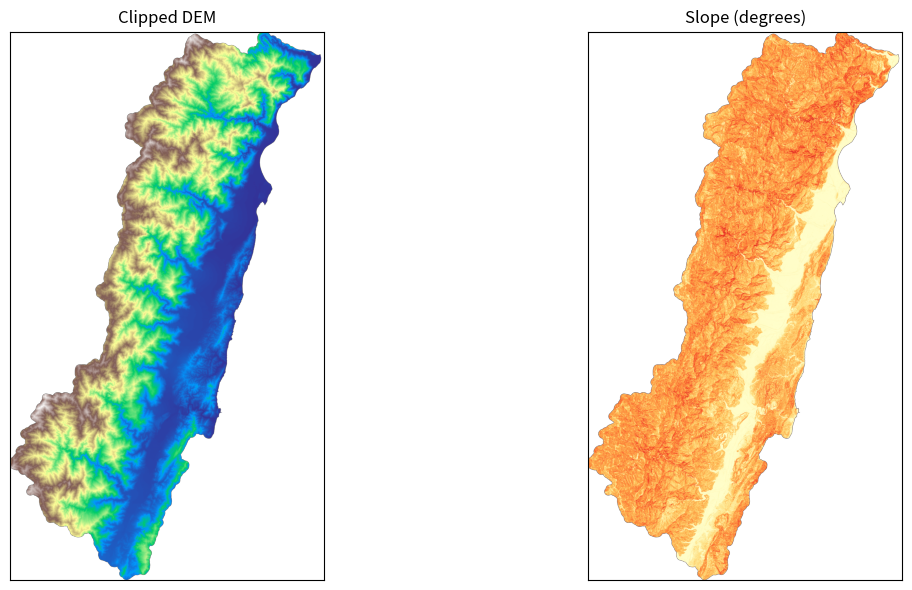

In [6]:
elevation = dem_clipped.values.astype(float)
fill_value = float(np.nanmean(elevation))
elevation_filled = np.where(np.isfinite(elevation), elevation, fill_value)

dy, dx = np.gradient(elevation_filled, 20.0)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
slope[~np.isfinite(elevation)] = np.nan

slope_da = xr.DataArray(
    slope,
    coords=dem_clipped.coords,
    dims=dem_clipped.dims,
    attrs={"long_name": "slope_degrees"},
).rio.write_crs(dem_clipped.rio.crs)

print("Slope min / max / mean:", float(np.nanmin(slope)), float(np.nanmax(slope)), float(np.nanmean(slope)))
print("Pixels > 30 degrees:", float(np.nanmean(slope > 30) * 100), "%")

ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(elevation_filled, vert_exag=1, dx=20, dy=20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(elevation, cmap="terrain")
axes[0].set_title("Clipped DEM")
axes[1].imshow(slope, cmap="YlOrRd")
axes[1].set_title("Slope (degrees)")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()


## Captain's Log 5

Build 500m shelter buffers and run zonal statistics for mean elevation, elevation standard deviation, and max slope.


In [7]:
buffer_gdf = target_shelters.copy()
buffer_gdf["geometry"] = buffer_gdf.geometry.buffer(BUFFER_HIGH)

elevation_nodata = np.where(np.isfinite(elevation), elevation, -9999)
slope_nodata = np.where(np.isfinite(slope), slope, -9999)
affine = dem_clipped.rio.transform()

elev_stats = zonal_stats(
    buffer_gdf.geometry,
    elevation_nodata,
    affine=affine,
    nodata=-9999,
    stats=["mean", "std"],
)
slope_stats = zonal_stats(
    buffer_gdf.geometry,
    slope_nodata,
    affine=affine,
    nodata=-9999,
    stats=["max"],
)

target_shelters["mean_elevation"] = [row.get("mean") for row in elev_stats]
target_shelters["std_elevation"] = [row.get("std") for row in elev_stats]
target_shelters["max_slope"] = [row.get("max") for row in slope_stats]

target_shelters[["shelter_id", "name", "mean_elevation", "std_elevation", "max_slope"]].head()


,shelter_id,name,mean_elevation,std_elevation,max_slope
29,46,和平國小,27.502351,17.994240,45.473255
1272,1306,豐南社區活動中心,299.459149,13.260633,41.046371
1298,1332,玉寶宮,240.630908,7.838210,29.891893
1308,1342,永豐社區活動中心,257.456815,22.753039,32.286249
1316,1350,富里老人文康中心,238.324347,18.284005,30.526334


## Captain's Log 6

Apply the composite risk logic from the assignment and export the audit table.


In [8]:
def classify_risk(row):
    if row["distance_to_river_m"] < 500 and pd.notna(row["max_slope"]) and row["max_slope"] > SLOPE_THRESHOLD:
        return "very_high"
    if row["distance_to_river_m"] < 500 or (pd.notna(row["max_slope"]) and row["max_slope"] > SLOPE_THRESHOLD):
        return "high"
    if row["distance_to_river_m"] < 1000 and pd.notna(row["mean_elevation"]) and row["mean_elevation"] < ELEVATION_LOW:
        return "medium"
    return "low"


target_shelters["risk_level"] = target_shelters.apply(classify_risk, axis=1)
target_shelters["risk_rank"] = target_shelters["risk_level"].map({"very_high": 0, "high": 1, "medium": 2, "low": 3})

audit_df = (
    target_shelters.sort_values(
        ["risk_rank", "max_slope", "distance_to_river_m", "shelter_id"],
        ascending=[True, False, True, True],
    )[
        [
            "shelter_id",
            "name",
            "COUNTYNAME",
            "TOWNNAME",
            "capacity",
            "distance_to_river_m",
            "river_distance_category",
            "mean_elevation",
            "std_elevation",
            "max_slope",
            "risk_level",
        ]
    ]
    .rename(columns={"COUNTYNAME": "county_name", "TOWNNAME": "town_name"})
    .reset_index(drop=True)
)

audit_path = OUTPUT_DIR / "terrain_risk_audit.json"
with audit_path.open("w", encoding="utf-8") as handle:
    json.dump(audit_df.to_dict(orient="records"), handle, ensure_ascii=False, indent=2)

audit_df.head(10)


,shelter_id,name,county_name,town_name,capacity,distance_to_river_m,river_distance_category,mean_elevation,std_elevation,max_slope,risk_level
0,3149,七星潭社區活動中心,花蓮縣,新城鄉,27,104.625729,<500m,17.134883,11.921133,88.731859,very_high
1,2999,中正體育館,花蓮縣,花蓮市,593,163.580938,<500m,9.303737,4.895354,88.730469,very_high
2,3437,富世活動中心,花蓮縣,秀林鄉,100,300.925487,<500m,87.577001,52.449728,70.428532,very_high
3,1883,奇美社區活動中心,花蓮縣,瑞穗鄉,20,188.393395,<500m,63.718883,32.614023,66.628512,very_high
4,2950,銅門收容所,花蓮縣,秀林鄉,70,190.714085,<500m,179.414936,50.599505,65.691610,very_high
5,2333,磯崎村辦公處活動中心,花蓮縣,豐濱鄉,0,89.997441,<500m,83.961822,44.046407,63.652254,very_high
6,1555,樂合社區活動中心,花蓮縣,玉里鎮,35,205.641666,<500m,188.470148,52.270146,62.642926,very_high
7,2357,森榮里辦公處,花蓮縣,鳳林鎮,30,101.686392,<500m,210.267068,59.575780,61.390305,very_high
8,2130,豐濱國中禮堂,花蓮縣,豐濱鄉,0,135.142360,<500m,36.283165,34.905656,57.256419,very_high
9,1528,卓樂社區活動中心,花蓮縣,卓溪鄉,50,406.429698,<500m,231.148161,60.508599,57.183616,very_high


## Captain's Log 7

Create the final hillshade map with river polygons, export the assignment-required Top 10 scatter plot, and add a supplementary ranked chart for dense counties where labels overlap too much.


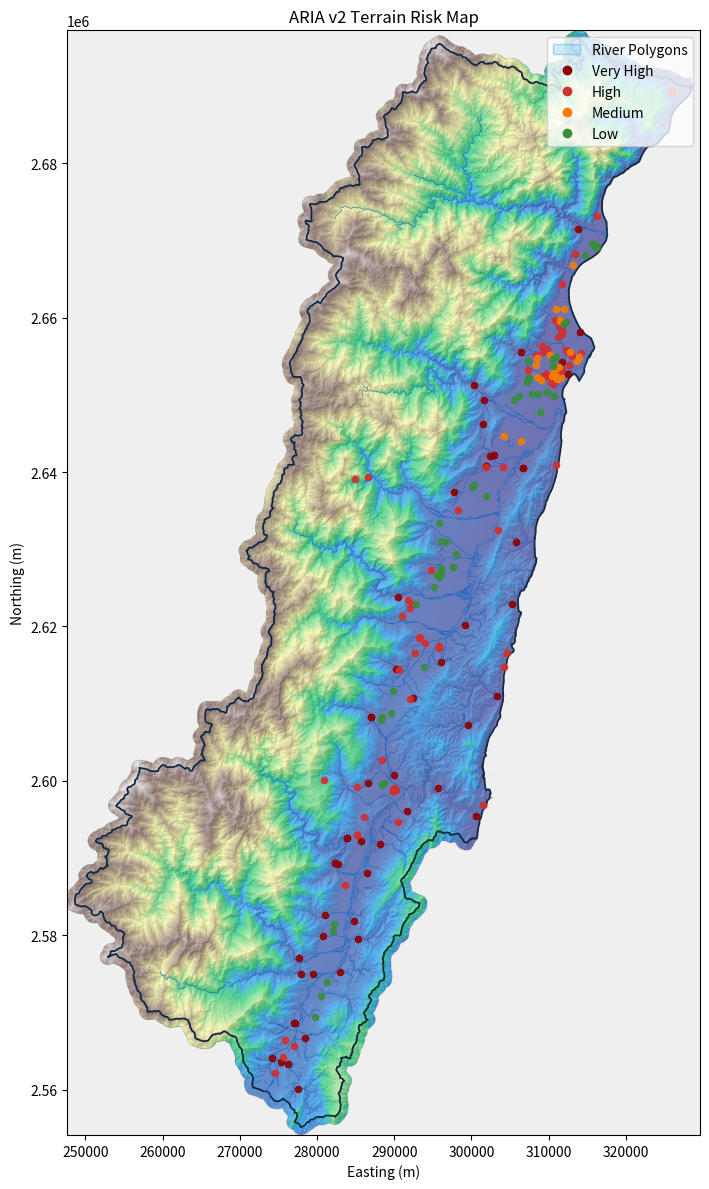

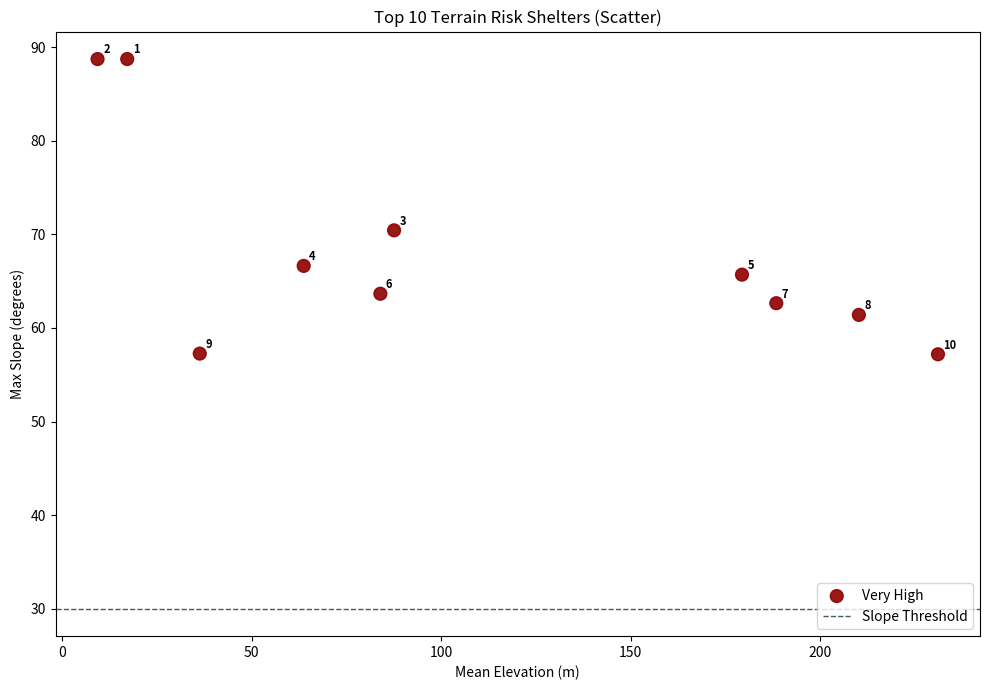

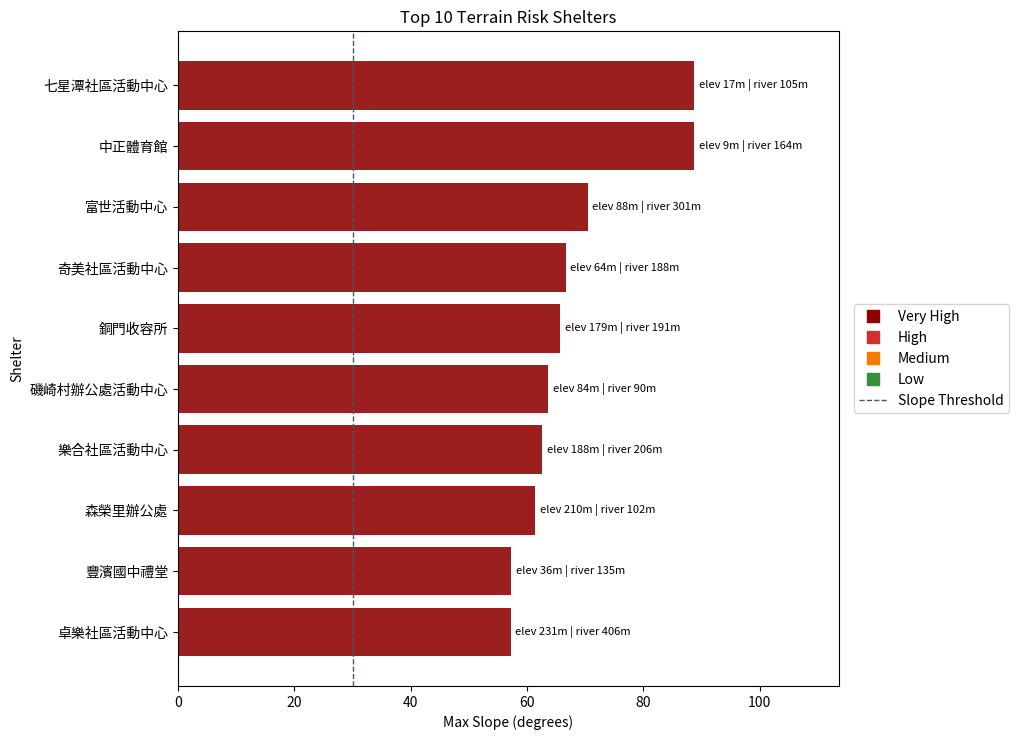

Saved: /content/drive/MyDrive/Colab Notebooks/outputs/homework4/terrain_risk_audit.json
Saved: /content/drive/MyDrive/Colab Notebooks/outputs/homework4/terrain_risk_map.png
Saved: /content/drive/MyDrive/Colab Notebooks/outputs/homework4/terrain_risk_top10_scatter.png
Saved: /content/drive/MyDrive/Colab Notebooks/outputs/homework4/terrain_risk_top10_ranked.png


In [9]:
left, bottom, right, top = dem_clipped.rio.bounds()
extent = (left, right, bottom, top)
risk_colors = {
    "very_high": "#8e0000",
    "high": "#d32f2f",
    "medium": "#f57c00",
    "low": "#388e3c",
}

fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(elevation, extent=extent, origin="upper", cmap="terrain", alpha=0.95)
ax.imshow(hillshade, extent=extent, origin="upper", cmap="gray", alpha=0.35)
rivers_in_county.plot(ax=ax, color="#4fc3f7", alpha=0.18, linewidth=0, zorder=2)
rivers_in_county.boundary.plot(ax=ax, color="#1565c0", linewidth=0.35, alpha=0.55, zorder=3)
county_boundary.boundary.plot(ax=ax, color="#102a43", linewidth=1.3)
for level in ["very_high", "high", "medium", "low"]:
    subset = target_shelters[target_shelters["risk_level"] == level]
    if subset.empty:
        continue
    subset.plot(ax=ax, markersize=20, color=risk_colors[level], alpha=0.9, zorder=4)
ax.set_title("ARIA v2 Terrain Risk Map")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
map_handles = [
    Patch(facecolor="#4fc3f7", edgecolor="#1565c0", alpha=0.25, label="River Polygons"),
    Line2D([0], [0], marker="o", linestyle="", color=risk_colors["very_high"], markersize=6, label="Very High"),
    Line2D([0], [0], marker="o", linestyle="", color=risk_colors["high"], markersize=6, label="High"),
    Line2D([0], [0], marker="o", linestyle="", color=risk_colors["medium"], markersize=6, label="Medium"),
    Line2D([0], [0], marker="o", linestyle="", color=risk_colors["low"], markersize=6, label="Low"),
]
ax.legend(handles=map_handles, loc="upper right")
map_path = OUTPUT_DIR / "terrain_risk_map.png"
fig.tight_layout()
fig.savefig(map_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

top10 = target_shelters.sort_values(["risk_rank", "max_slope", "distance_to_river_m"], ascending=[True, False, True]).head(10)
top10 = top10.copy()
top10["display_name"] = top10["name"].str.slice(0, 28)
top10["rank_label"] = [str(i) for i in range(1, len(top10) + 1)]

fig, ax = plt.subplots(figsize=(10, 7))
for level in ["very_high", "high", "medium", "low"]:
    subset = top10[top10["risk_level"] == level]
    if subset.empty:
        continue
    ax.scatter(
        subset["mean_elevation"],
        subset["max_slope"],
        color=subset["risk_level"].map(risk_colors),
        s=85,
        alpha=0.9,
        label=level.replace("_", " ").title(),
    )
for _, row in top10.iterrows():
    ax.annotate(
        row["rank_label"],
        (row["mean_elevation"], row["max_slope"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        fontweight="bold",
    )
ax.axhline(SLOPE_THRESHOLD, color="#455a64", linestyle="--", linewidth=1.0, label="Slope Threshold")
ax.set_title("Top 10 Terrain Risk Shelters (Scatter)")
ax.set_xlabel("Mean Elevation (m)")
ax.set_ylabel("Max Slope (degrees)")
ax.legend(loc="lower right")
scatter_path = OUTPUT_DIR / "terrain_risk_top10_scatter.png"
fig.tight_layout()
fig.savefig(scatter_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 7.5))
bars = ax.barh(
    top10["display_name"],
    top10["max_slope"],
    color=top10["risk_level"].map(risk_colors),
    alpha=0.88,
)
for bar, (_, row) in zip(bars, top10.iterrows()):
    elev_text = "nan" if pd.isna(row["mean_elevation"]) else f"{row['mean_elevation']:.0f}"
    river_text = "nan" if pd.isna(row["distance_to_river_m"]) else f"{row['distance_to_river_m']:.0f}"
    label = f"elev {elev_text}m | river {river_text}m"
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8,
    )
ax.axvline(SLOPE_THRESHOLD, color="#455a64", linestyle="--", linewidth=1.0, label="Slope Threshold")
ax.set_title("Top 10 Terrain Risk Shelters")
ax.set_xlabel("Max Slope (degrees)")
ax.set_ylabel("Shelter")
ax.invert_yaxis()
ax.set_xlim(0, max(top10["max_slope"].max() * 1.28, SLOPE_THRESHOLD * 1.2))
bar_handles = [
    Line2D([0], [0], marker="s", linestyle="", color=risk_colors["very_high"], markersize=8, label="Very High"),
    Line2D([0], [0], marker="s", linestyle="", color=risk_colors["high"], markersize=8, label="High"),
    Line2D([0], [0], marker="s", linestyle="", color=risk_colors["medium"], markersize=8, label="Medium"),
    Line2D([0], [0], marker="s", linestyle="", color=risk_colors["low"], markersize=8, label="Low"),
    Line2D([0], [0], color="#455a64", linestyle="--", linewidth=1.0, label="Slope Threshold"),
]
ax.legend(handles=bar_handles, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True, borderaxespad=0.6)
ranked_path = OUTPUT_DIR / "terrain_risk_top10_ranked.png"
fig.tight_layout(rect=(0, 0, 0.86, 1))
fig.savefig(ranked_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved:", audit_path)
print("Saved:", map_path)
print("Saved:", scatter_path)
print("Saved:", ranked_path)


## Captain's Log 8

AI diagnostic log summary:

- `dem_20m_hualien.tif` may not carry CRS metadata, so the notebook explicitly writes `EPSG:3826` before clipping.
- The assignment still asks for a scatter plot, but dense counties such as New Taipei can produce heavy label overlap. The notebook therefore keeps the required scatter plot and also exports a ranked chart for readability.
- If zonal statistics return `NaN`, the first checks should be CRS alignment and whether the 500m shelter buffer extends outside the clipped DEM.
- The slope calculation uses `np.gradient(..., 20)` so the pixel spacing matches the 20m DEM resolution.
